In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

In [2]:
df = pd.read_csv('./../../../dataset/docimsentv1/docimsentv1.csv')
df.head()

,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,sentiment
0,negative_001.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",16:9,horizontal,535824,16:9,horizontal,110418,0.206071,negative
1,negative_002.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative
2,negative_003.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],16:9,horizontal,810000,NaN,NaN,0,0.000000,negative
3,negative_004.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],4:3,horizontal,50246,NaN,NaN,0,0.000000,negative
4,negative_006.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,R. TURKEY TO HOST TALKS?\nWORLD\nAT WAR\nR. BR...,"[{'x': 62, 'y': 28}, {'x': 641, 'y': 28}, {'x'...",16:9,horizontal,292320,16:9,horizontal,172542,0.590250,negative


# Duplicate Check

In [3]:
sentiments = df['sentiment']
sentiments.value_counts()

sentiment
positive    752
neutral     656
negative    646
Name: count, dtype: int64

In [4]:
negatives = df[df['sentiment']=='negative']
neutrals = df[df['sentiment']=='neutral']
positives = df[df['sentiment']=='positive']

In [6]:
import os
import hashlib
from tqdm.notebook import tqdm

# Path to your folder of images
folder_path = './../../../dataset/docimsentv1'

# Dictionary to store hashes
hash_dict = {}

# Get all filenames first
filenames = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f)) and "csv" not in f]


# Loop through files
for filename in tqdm(filenames, desc="Scanning images"):
    file_path = os.path.join(folder_path, filename)
    
    # Only process files (not subfolders)
    if os.path.isfile(file_path):
        # Read file in binary mode
        with open(file_path, 'rb') as f:
            file_data = f.read()
            file_hash = hashlib.md5(file_data).hexdigest()  # You can also use sha256

        # Store duplicates
        if file_hash in hash_dict:
            hash_dict[file_hash].append(filename)
        else:
            hash_dict[file_hash] = [filename]

# Print duplicates
duplicates = {h: files for h, files in hash_dict.items() if len(files) > 1}

if duplicates:
    print(f"Found {len(duplicates)} duplicate images:")
    for h, files in duplicates.items():
        print(f"\nHash: {h}")
        for f in files:
            print(f"  - {f}")
else:
    print("No duplicate images found.")

Scanning images:   0%|          | 0/2054 [00:00<?, ?it/s]

No duplicate images found.


In [7]:
from collections import defaultdict
# Count duplicates by sentiment
sentiment_counts = defaultdict(int)

for dup_list in tqdm(duplicates.values(), desc="Sentiment wise scanning:"):
    for filename in dup_list:
        sentiment = filename.split('_')[0].lower()  # e.g. 'negative_001.png' → 'negative'
        sentiment_counts[sentiment] += 1

# Display results
if sentiment_counts:
    print("\nDuplicate image count by sentiment:")
    for sentiment, count in sentiment_counts.items():
        print(f"  {sentiment}: {count} duplicates")
else:
    print("No duplicate images found.")

Sentiment wise scanning:: 0it [00:00, ?it/s]

No duplicate images found.


In [10]:
# Count duplicate **groups** by sentiment
sentiment_group_counts = defaultdict(int)

duplicate_found = True # Duplicates exist

for dup_list in tqdm(duplicates.values(), desc="Sentiment wise scanning:"):
    # Use the first filename in the group to infer sentiment
    sentiment = dup_list[0].split('_')[0].lower()
    sentiment_group_counts[sentiment] += 1

# Display results
if sentiment_group_counts:
    print("\nDuplicate group count by sentiment:")
    for sentiment, count in sentiment_group_counts.items():
        print(f"  {sentiment}: {count} duplicate groups")
else:
    print("No duplicate images found.")
    flag = False

Sentiment wise scanning:: 0it [00:00, ?it/s]

No duplicate images found.


## Remove duplicates

In [11]:
import os
import hashlib
import shutil
from tqdm.notebook import tqdm

source_folder = '/kaggle/input/musait/dataset/basket'
destination_folder = 'basket_unique'

# Create destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

hash_set = set()
unique_files = []

if duplicate_found == False:
    # Get all image filenames
    filenames = [f for f in os.listdir(source_folder) if os.path.isfile(os.path.join(source_folder, f))]
    
    # Process with progress bar
    for filename in tqdm(filenames, desc="Filtering unique images"):
        file_path = os.path.join(source_folder, filename)
    
        # Hash image content
        with open(file_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
    
        # If new hash, copy file to unique folder
        if file_hash not in hash_set:
            hash_set.add(file_hash)
            shutil.copy(file_path, os.path.join(destination_folder, filename))
            unique_files.append(filename)
    
    print(f"\n✔️ Finished! {len(unique_files)} unique images copied to: {destination_folder}")
else:
    print("No duplicates! Hence no need for filtering any uniques!")

No duplicates! Hence no need for filtering any uniques!


In [13]:
import zipfile

if duplicate_found == False:
    # Define zip filename
    zip_filename = 'unique_images.zip'
    
    # Create a zip file from the output folder
    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        for root, dirs, files in tqdm(os.walk(destination_folder), desc="Scanning files:"):
            # print(root,dirs)
            # print("_"*50)
            for file in files:
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, destination_folder)
                zipf.write(full_path, arcname)
    
    print(f"\n📦 Zipped folder ready: {zip_filename}")
else:
    print("No duplicates! Hence no need for zipping any uniques!")

No duplicates! Hence no need for zipping any uniques!


# Feature analysis tables

In [14]:
# Create cross-tabulation table
sent_imgOr_table = pd.crosstab(df['sentiment'], df['img_or'])

print("____________________ Sentiment & Image Orientation contingency table ____________________")
print()
print(sent_imgOr_table)

____________________ Sentiment & Image Orientation contingency table ____________________

img_or     box  horizontal  other  vertical
sentiment                                  
negative    81         510     19        36
neutral    175         385     17        79
positive   249         237     11       255


In [15]:
# Create cross-tabulation table
sent_imgAr_table = pd.crosstab(df['sentiment'], df['img_ar'])

print("____________________ Sentiment & Image Aspect Ratio contingency table ____________________")
print()
print(sent_imgAr_table)

____________________ Sentiment & Image Aspect Ratio contingency table ____________________

img_ar     16:9  1:1  21:9  2:1  2:3  3:2  3:4  4:3  5:4  9:16  Other
sentiment                                                            
negative    346   81     2    1    0   51   35  107    3     1     19
neutral     276  175     7    3    7   35   69   56    8     3     17
positive     95  249     0    1    4   71  251   64    6     0     11


In [16]:
# Create cross-tabulation table
sent_txtOr_table = pd.crosstab(df['sentiment'], df['txt_or'])

print("____________________ Sentiment & Text Orientation contingency table ____________________")
print()
print(sent_txtOr_table)

____________________ Sentiment & Text Orientation contingency table ____________________

txt_or     box  horizontal  other  vertical
sentiment                                  
negative    67         323    171        41
neutral     97         244    196        85
positive   145         281    175       121


In [17]:
# Create cross-tabulation table
sent_txtAr_table = pd.crosstab(df['sentiment'], df['txt_ar'])

print("____________________ Sentiment & Text Aspect Ratio contingency table ____________________")
print()
print(sent_txtAr_table)

____________________ Sentiment & Text Aspect Ratio contingency table ____________________

txt_ar     16:9  1:1  21:9  2:1  2:3  2:5  3:2  3:4  4:3  5:4  9:16  Other
sentiment                                                                 
negative    144   67    36   18    5    1   44   33   75    6     2    171
neutral      88   97    41   23   14    5   31   60   54    7     6    196
positive     52  145    38   24   11    2   39  105  114   14     3    175


In [18]:
# Create cross-tabulation table
txtAr_imgAr_table = pd.crosstab(df['txt_ar'],df['img_ar'])

print("____________________ Text Aspect Ratio & Image Aspect Ratio contingency table ____________________")
print()
print(txtAr_imgAr_table)

____________________ Text Aspect Ratio & Image Aspect Ratio contingency table ____________________

img_ar  16:9  1:1  21:9  2:1  2:3  3:2  3:4  4:3  5:4  9:16  Other
txt_ar                                                            
16:9     213   18     0    0    1   11   21   13    2     0      5
1:1       40  184     1    0    0   16   44   19    3     0      2
21:9      67   14     1    0    0    9   12    7    1     0      4
2:1       42    5     0    0    0    3   11    3    0     0      1
2:3        3    5     0    0    4    3   15    0    0     0      0
2:5        0    1     0    0    1    0    4    0    0     2      0
3:2       37   22     0    0    2   21    9   21    0     0      2
3:4       11   48     1    0    2    4  120   11    0     1      0
4:3       50   65     0    0    0   23   27   72    1     0      5
5:4        4    8     0    0    1    3    3    5    3     0      0
9:16       1    5     0    0    0    1    3    0    0     1      0
Other    229  107     4    3 

In [19]:
# Create cross-tabulation table
txtOr_imgOr_table = pd.crosstab(df['txt_or'], df['img_or'])

print("____________________ Text Orientation & Image Orientation contingency table ____________________")
print()
print(txtOr_imgOr_table)

____________________ Text Orientation & Image Orientation contingency table ____________________

img_or      box  horizontal  other  vertical
txt_or                                      
box         184          79      2        44
horizontal  132         612     17        87
other       107         336     22        77
vertical     59          35      0       153


# Hypothesis Testing on Text Orientation

In [20]:
import os
from PIL import Image
from collections import defaultdict, Counter
from scipy.stats import chi2_contingency

import numpy as np
import pandas as pd

data = sent_txtOr_table.copy()

# Optional: Set labels
sentiments = ['positive', 'negative', 'neutral']
orientations = ['box', 'horizontal', 'other', 'vertical']

# Contingency table

# Chi-square test
chi2, p, dof, expected = chi2_contingency(data)

print(f"Chi-square statistic = {chi2:.3f}")
print(f"p-value = {p}")
print(f"Degrees of freedom = {dof}")

Chi-square statistic = 69.664
p-value = 4.79207730294694e-13
Degrees of freedom = 6


In [21]:
sent_txtOr_table

txt_or,box,horizontal,other,vertical
sentiment,,,,
negative,67,323,171,41
neutral,97,244,196,85
positive,145,281,175,121


In [22]:
print("Expected frequencies (under H_0: No relationship):")
pd.DataFrame(np.round(expected, 2), index=sentiments, columns=orientations)

Expected frequencies (under H_0: No relationship):


,box,horizontal,other,vertical
positive,95.59,262.33,167.67,76.41
negative,98.77,271.05,173.24,78.95
neutral,114.64,314.62,201.09,91.64


In [23]:
print(f"p-value = {p}")
# Decision
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: There is a relationship between orientation and sentiment.")
else:
    print("Fail to reject the null hypothesis: No significant relationship found.")

p-value = 4.79207730294694e-13
Reject the null hypothesis: There is a relationship between orientation and sentiment.


# Hypothesis Testing on Image Orientation

In [24]:
import os
from PIL import Image
from collections import defaultdict, Counter
from scipy.stats import chi2_contingency

import numpy as np
import pandas as pd

data = sent_imgOr_table.copy()

# Optional: Set labels
sentiments = ['positive', 'negative', 'neutral']
orientations = ['box', 'horizontal', 'other', 'vertical']

# Contingency table

# Chi-square test
chi2, p, dof, expected = chi2_contingency(data)

print(f"Chi-square statistic = {chi2:.3f}")
print(f"p-value = {p}")
print(f"Degrees of freedom = {dof}")

Chi-square statistic = 383.301
p-value = 1.0858308190443789e-79
Degrees of freedom = 6


In [25]:
print("Expected frequencies:")
pd.DataFrame(np.round(expected, 2), index=sentiments, columns=orientations)

Expected frequencies:


,box,horizontal,other,vertical
positive,158.83,356.02,14.78,116.37
negative,161.29,361.53,15.01,118.17
neutral,184.89,414.44,17.21,135.46


In [26]:
print(f"p-value = {p}")
# Decision
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: There is a relationship between orientation and sentiment.")
else:
    print("Fail to reject the null hypothesis: No significant relationship found.")

p-value = 1.0858308190443789e-79
Reject the null hypothesis: There is a relationship between orientation and sentiment.


# Hypothesis Testing on Text-Image Ratio

In [27]:
type(df['txt_img_ratio'][0])

numpy.float64

In [28]:
import pandas as pd
import numpy as np

# Example: Ensure the column is numeric
col = pd.to_numeric(df['txt_img_ratio'], errors='coerce')

# Define bins (10 equal-width bins between 0 and 1)
bins = np.linspace(0, 1, 11)  # 11 edges = 10 bins
labels = [f"{round(bins[i],1)}–{round(bins[i+1],1)}" for i in range(len(bins)-1)]

# Add binned column
txt_img_bin = pd.cut(col, bins=bins, labels=labels, include_lowest=True)
df = pd.concat([df.iloc[:,:-1], txt_img_bin, df.iloc[:,-1]], axis=1)

In [29]:
df.columns.values[-2] = 'txt_img_ratio_bin'

In [30]:
df.head()

,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,txt_img_ratio_bin,sentiment
0,negative_001.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",16:9,horizontal,535824,16:9,horizontal,110418,0.206071,0.2–0.3,negative
1,negative_002.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,0.3–0.4,negative
2,negative_003.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],16:9,horizontal,810000,NaN,NaN,0,0.000000,0.0–0.1,negative
3,negative_004.jpg,/kaggle/input/musait/dataset/basket/negative_0...,0,NaN,[],4:3,horizontal,50246,NaN,NaN,0,0.000000,0.0–0.1,negative
4,negative_006.jpg,/kaggle/input/musait/dataset/basket/negative_0...,1,R. TURKEY TO HOST TALKS?\nWORLD\nAT WAR\nR. BR...,"[{'x': 62, 'y': 28}, {'x': 641, 'y': 28}, {'x'...",16:9,horizontal,292320,16:9,horizontal,172542,0.590250,0.5–0.6,negative


/home/soham/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


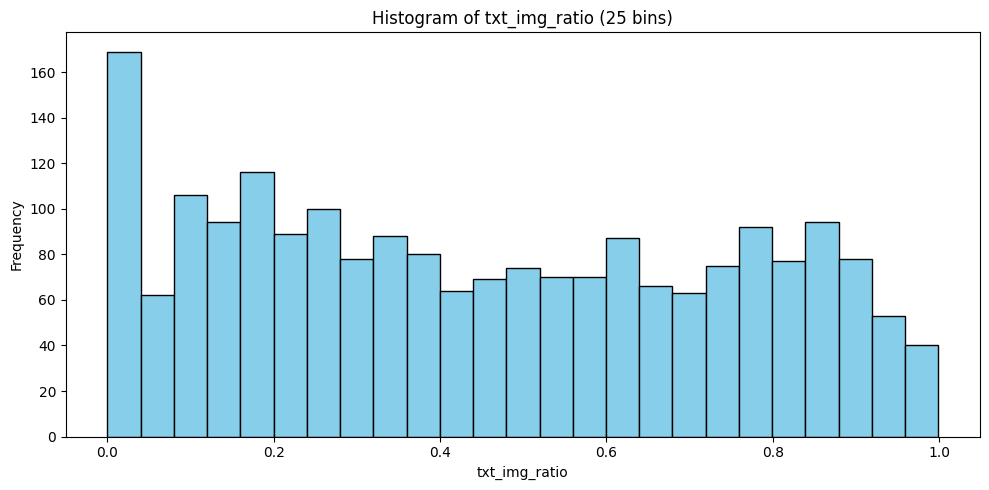

In [31]:
import matplotlib.pyplot as plt

# Plot histogram directly from the data
plt.figure(figsize=(10, 5))
plt.hist(df['txt_img_ratio'], bins=25, color='skyblue', edgecolor='black')

plt.xlabel('txt_img_ratio')
plt.ylabel('Frequency')
plt.title('Histogram of txt_img_ratio (25 bins)')
plt.tight_layout()
plt.savefig("txt_img_ratio.png")
plt.show()

In [32]:
# Create cross-tabulation table
sent_ratioBin_table = pd.crosstab(df['sentiment'], df['txt_img_ratio_bin'])

print("____________________ Text Orientation & Image Orientation contingency table ____________________")
print()
sent_ratioBin_table

____________________ Text Orientation & Image Orientation contingency table ____________________



txt_img_ratio_bin,0.0–0.1,0.1–0.2,0.2–0.3,0.3–0.4,0.4–0.5,0.5–0.6,0.6–0.7,0.7–0.8,0.8–0.9,0.9–1.0
sentiment,,,,,,,,,,
negative,78,70,49,45,37,48,77,73,106,63
neutral,105,75,55,67,46,57,62,79,68,42
positive,99,121,126,92,89,70,46,48,40,21


In [33]:
labels

['0.0–0.1',
 '0.1–0.2',
 '0.2–0.3',
 '0.3–0.4',
 '0.4–0.5',
 '0.5–0.6',
 '0.6–0.7',
 '0.7–0.8',
 '0.8–0.9',
 '0.9–1.0']

In [34]:
import os
from PIL import Image
from collections import defaultdict, Counter
from scipy.stats import chi2_contingency

import numpy as np
import pandas as pd

data = sent_ratioBin_table.copy()

# Optional: Set labels
sentiments = ['positive', 'negative', 'neutral']
labels = ['0.0–0.1', '0.1–0.2', '0.2–0.3', '0.3–0.4', '0.4–0.5', '0.5–0.6', 
          '0.6–0.7', '0.7–0.8', '0.8–0.9', '0.9–1.0']

# Contingency table

# Chi-square test
chi2, p, dof, expected = chi2_contingency(data)

print(f"Chi-square statistic = {chi2:.3f}")
print(f"p-value = {p}")
print(f"Degrees of freedom = {dof}")

Chi-square statistic = 170.505
p-value = 7.204317556966989e-27
Degrees of freedom = 18


In [35]:
print("Expected frequencies:")
pd.DataFrame(np.round(expected, 2), index=sentiments, columns=labels)

Expected frequencies:


,0.0–0.1,0.1–0.2,0.2–0.3,0.3–0.4,0.4–0.5,0.5–0.6,0.6–0.7,0.7–0.8,0.8–0.9,0.9–1.0
positive,88.69,83.66,72.34,64.16,54.10,55.04,58.18,62.90,67.30,39.63
negative,90.06,84.95,73.46,65.15,54.93,55.89,59.08,63.88,68.35,40.24
neutral,103.24,97.39,84.21,74.69,62.97,64.07,67.73,73.22,78.35,46.13


In [36]:
print(f"p-value = {p}")
# Decision
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: There is a relationship between txt_img_ratio and sentiment.")
else:
    print("Fail to reject the null hypothesis: No significant relationship found.")

p-value = 7.204317556966989e-27
Reject the null hypothesis: There is a relationship between txt_img_ratio and sentiment.
